# Imports

In [ ]:
import time
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from itertools import combinations

# langchain imports
# from langchain.llms import Ollama, HuggingFacePipeline
#from langchain_openrouter import OpenRouter
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
#from langchain_google_vertexai import VertexAI

from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCaseParams, LLMTestCase


# traditional ML imports
from scipy.stats import ttest_ind, zscore
from summarytools import dfSummary

In [ ]:
# # finds .env file and loads the vars
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "Key not found")
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "Key not found")
#openai_org = os.getenv("OPENAI_ORG", "Organization not found")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

In [11]:
def create_openrouter_llm(model_name, temperature=0.7):
    return ChatOpenAI(
        model=model_name,
        openai_api_key=OPENROUTER_API_KEY,
        openai_api_base=OPENROUTER_BASE_URL,
        temperature=temperature
    )


In [ ]:
models = {
    "Claude4": create_openrouter_llm("anthropic/claude-sonnet-4")
}

# Initialization

In [15]:
READ_FROM_PICKLE = True

In [16]:
if READ_FROM_PICKLE:
    malicious_df = pd.read_pickle("data/malicious_features_numeric.pkl")
    benign_df = pd.read_pickle("data/benign_features_numeric.pkl")

# EDA

## Statistical

In [17]:
def summarize_dataset(df):
    summary = f"""
    The dataset contains {len(df)} rows and it contains a network packet capture that was generated using Wireshark in an enterprize network.
    Study the first 100 rows of the dataset and try to understand what it describes:\n {df.head(100)}"
    Below are the summary statistics of the dataset\n {df.describe()}.
    """
    with open("data/df_summary_mal.txt", "r") as f:
        summary += f"A summary that includes statistics, histograms is given below \n {f.read()}." 
    summary += "Identify any anomalies in this time series dataset. Justify your conclusions based on known detections and security attacks." 
    return summary

In [18]:
dfSummary(malicious_df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Timestamp[float64],Mean (sd) : 1540450214.8 (2080.2)min < med < max:1540446382.9 < 1540450432.6 < 1540453519.8IQR (CV) : 3618.0 (740512.8),"154,090 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAkxJREFUeJzt3b9u2mAUhvFjtyATkD/xp3ABHbMhsXABHXuxvYQODJ0ZunRiQ0KWEW6sGtsd2qpTEmwntV/3+a3o8Hl4xKeEI+GVZWlA1/ltPwBwi7dtPwD6w/O8kZkNa47/KMvy4bEXCbVnGsbim1lRczaYzWYfnHPjOsPn8znyPO/TY7ESao94njeaz+cfwzCcVp3N83yQJMn7yWTyzff9rOp8lmWBmd1vNpsvi8XiXGU2juNgt9tNT6fT0MwI9T8wDMNwut1uH5xzaZXBw+Ew3e/379br9dfVahVVPfj3/F0QBNlyufxedd7MRk+9SKgd0/DqDouiGDjnoqqxRFE0MjMbj8dpndD+zL8WQu2QJle32a/rN8/z+zRNP5tZnU+1ziLUbql9dZv9vX6v1+ub13i4NhFqBznnOnn9tol/+EMCoUICoUICoUICoUICoUICoUICoUICoUICoULCs1+htriI23Re8eywKIpBzTN77clQ21zEbTKvenaft5+aeu4Tte1F3Frzqmf3efupqZu2p+ps87zUIm6dedWz+7z91BR/TEECoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoUICoULCTb8uHcdxUPWNL5dLYGaWJElwPB7v/uW86tmqz910/pa+fgIzj0bVAseHGwAAAABJRU5ErkJggg=="">",0(0.0%)
2,Source Port[float64],Mean (sd) : 31461.6 (18801.8)min < med < max:0.0 < 32761.0 < 65267.0IQR (CV) : 28964.0 (1.7),"22,952 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAp1JREFUeJzt3L2O2kAYRuFvYEHmR7YQCnQ0KSOloOQicrG5hBRcAUWaVHRICIFw1sIY0iRSIq0W22Ov93XO08/OSD5ml/F63P1+N+C96zS9ACCPp6YX0EbOuYGZ9UsOv9zv9+cq19MGhFox59xgOp1+CcNwUmb86XQ6OOe+Euu/CLV6/TAMJ6vV6jmKoqTIwOPxGKzX68l+v++bGaH+hVBrEkVRMpvNfpYYOqh8MS3AlylIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIePiP07z/o6Wt1+vVUHn/R0ubr9ejT1Te/9HS2uuV650p3v/R0sbrxZcpSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSMh1mp8izwNtzd7xobb/o1aG6nugrVlzh9pmWdYzs9A5V2Z4eLvdeg3NbVbjzd3KUM3jQFuz5g61jeO4l6bp58Vi0e12u4XXnaZpkGXZpyRJvplZofNRfec2q/fmbmuoZuZ1oK1ZA4faXi6XpyAIhsvlMpnP54ei47fb7WSz2Qyv12v3reeu++ZudaiqRqNRqRvscDh431xl5/6ttpubb/2QQKiQQKiQwN+oqIzn9tarW1uEikr4bm892toiVFTCZ3srz9ZWraFW8KSjY2a3EuO8ntCYea3de25lHttbr25t1Raq76+CLMt6cRx/HI/HPzqdTlpkrM8TGjO/tfvOjZfVFmpFT1k+LJfL70XH+zyhMfNbu+/ceFmuUI/HY1D0B5/P58JjqhbHcbDb7YZFx1Wx9jJz/5nXd91qc+fp6xeVq4p5WAui0AAAAABJRU5ErkJggg=="">",0(0.0%)
3,Destination Port[float64],Mean (sd) : 6758.4 (7691.4)min < med < max:23.0 < 8280.0 < 65267.0IQR (CV) : 10187.0 (0.9),"3,691 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAl1JREFUeJzt2DFuGkEYhuFvAkaLlcxoQaLkApFyAPq0PqzbdCk4gW9Ag5AQXoTNxrBsDhAlNrsg+Mj79P/4L14t4wl1XQu4dp8uvQDwEd1zHh5C6EvqtTjira7r7an2ga+zhRpC6A+Hw4cYY970jPV6vQohPBIrzvlF7cUY88lksk0plccOF0WRTafTfLlc9iQR6n/urD/9kpRSKkej0WvD8f5Jl4Gtd0Ntcc+Mh8PhrsEc8Id/htrmnrnb7bKqqr6WZflTUtMvKiDp/S9q43vmbDbLn56e7vf7fafFfoCkD95Rm9wzV6sV90ucDA/+sECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosECosNC99ALnEkLoS+q1OOKtruvtqfZBOzcZagihPxwOH2KMedMz1uv1KoTwSKzX4SZDldSLMeaTyWSbUiqPHS6KIptOp/lyuexJItQrcKuhSpJSSuVoNHptON4/6TJohX+mYIFQYYFQYeGm76htVFV1JymGEJqMX+xpq+Wz3NU+yX0o1KIosmMP3mw2mSS9vLxki8Xi/tj5oiiyqqq6ahZLPBwO3SZ7S9J8Pv+y2+2+jcfjTqfTOfrV4Pn5eRNC+CHp6NmWssFg8D2l9LnJ8AX3lqRfdV3/9e/+Bq+dmDeeP15hAAAAAElFTkSuQmCC"">",0(0.0%)
4,Payload[object],"1. Raw2. Padding3. 4. DNS Qry ""b'xmpp.samsungsmartca5. DNS Ans 6. DNS Qry ""b'xmpp.samsungsmartca7. DNS Qry ""b'10024backup.broadli8. DNS Qry ""b'10024main.broadlink9. DNS Qry ""b'www.baidu.com.'"" 10. DNS Qry ""b'authentication.eye411. 

In [20]:
malicious_data_summary = summarize_dataset(malicious_df)
prompt_template = PromptTemplate(
    input_variables=["malicious_data_summary"],
    template="Analyze this dataset and identify anomalies and trends:\n{malicious_data_summary}",
)

In [22]:
malicious_data_summary

'\n    The dataset contains 154090 rows and it contains a network packet capture that was generated using Wireshark in an enterprize network.\n    Study the first 100 rows of the dataset and try to understand what it describes:\n         Timestamp  Source Port  Destination Port  \\\n0    1.540446e+09      21074.0              80.0   \n1    1.540446e+09      20532.0            8280.0   \n7    1.540446e+09       2440.0              53.0   \n8    1.540446e+09         53.0            2440.0   \n9    1.540446e+09      21074.0              80.0   \n..            ...          ...               ...   \n128  1.540446e+09      52259.0             443.0   \n130  1.540446e+09      47815.0              80.0   \n131  1.540446e+09      59225.0            8000.0   \n132  1.540446e+09      48977.0              80.0   \n133  1.540446e+09      50861.0           10240.0   \n\n                                               Payload  Packet Length  \\\n0                                              Padding  

In [23]:
statistical_results = {}

for model_name, model in models.items():
    print(f"Running analysis with {model_name}...")

    start_time = time.time()

    # Create chain and execute
    response = model.invoke(
        prompt_template.format(malicious_data_summary=malicious_data_summary)
    )

    end_time = time.time()

    # Store results
    statistical_results[model_name] = {
        "response": response,
        "time_taken": round(end_time - start_time, 2),
    }

    print(f"\n{model_name} Response:\n{response}\n")
    print(f"Time Taken: {round(end_time - start_time, 2)} seconds\n")

Running analysis with Claude4...

Claude4 Response:
content="Based on my analysis of this enterprise network packet capture dataset, I've identified several significant anomalies and concerning patterns that suggest malicious activity:\n\n## **Key Anomalies Identified**\n\n### 1. **Suspicious DNS Activity**\n- **High volume of DNS queries** to unusual domains like `xmpp.samsungsmartcam.com` (7,099 packets - 4.6% of traffic)\n- **DNS tunneling indicators**: Multiple queries to domains like `10024backup.broadlink` and `10024main.broadlink`\n- This pattern is consistent with **DNS exfiltration** or **command & control (C2) communication**\n\n### 2. **Abnormal Port Usage Patterns**\n- **Port 8280**: Extremely high usage (median destination port) - not a standard service port\n- **Port 10240**: Significant traffic volume - unusual for enterprise networks\n- **Port 8000**: High frequency usage\n- These non-standard ports suggest **covert channels** or **backdoor communications**\n\n### 3. **

### Hypothesis testing
- Is the difference between two groups or variables statistically significant?
- Use t-test to compare means of two groups
  - assumes that data follows normal distribution
- Types of variables
  - dependent: the effect of a phenomenon. For example, how does number of HTTP requests mean that a network is compromised?
  - independent: the cause. The number of HTTP requests affects whether a network is compromised.

In [24]:
malicious_df.pop("Payload")

0                                                   Padding
1                                                   Padding
7         DNS Qry "b'xmpp.samsungsmartcam.com.Speedport_...
8                                                  DNS Ans 
9                                                   Padding
                                ...                        
764121                                                  Raw
764122                      DNS Qry "b'time.windows.com.'" 
764124                                              Padding
764125                                              Padding
764136    DNS Qry "b'north-america.pool.ntp.org.Speedpor...
Name: Payload, Length: 154090, dtype: object

In [25]:
def hypothesis_testing(df, col1, col2):
    group1 = df[col1]
    group2 = df[col2]
    pvalue = ttest_ind(group1, group2)[1]
    if pvalue < 0.05:
        return "The difference between {} and {} is statistically significant (p < 0.05)".format(
            col1, col2
        )
    else:
        return "The difference between {} and {} is not statistically significant (p >= 0.05)".format(
            col1, col2
        )

In [26]:
def get_column_combinations(df):
    df_columns = df.columns.tolist()
    pairs = list(combinations(df_columns, 2))

    return pairs

In [27]:
def all_hypotheses(df):
    # perform hypothesis testing for all combinations of columns
    all_column_pairs = get_column_combinations(malicious_df)
    hypotheses = ""
    for pair in all_column_pairs:
        hypotheses += hypothesis_testing(df, pair[0], pair[1])
    # ask model to explain
    explain = f"""
    Below there is all the hypothesis testing performed with ttest for all the possible combinations of the features of the dataset. 
    Extract logical conclusions based on the hypotheses testings. 
    Is there a difference between two groups of variables that is statistically significant? 
    Can you conclude if there are dependent or independent variables in the dataset? \n ** Hypotheses Tests ** {hypotheses}
    """
    
    return explain 

In [28]:
hypotheses = all_hypotheses(malicious_df)
prompt_template = PromptTemplate(
    input_variables=["hypotheses"],
    template="Analyze this dataset based on the hypotheses tests and identify anomalies and trends:\n{hypotheses}",
)

In [29]:
hypotheses_results = {}

for model_name, model in models.items():
    print(f"Running analysis with {model_name}...")

    start_time = time.time()

    # Create chain and execute
    response = model.invoke(prompt_template.format(hypotheses=hypotheses))

    end_time = time.time()

    # Store results
    hypotheses_results[model_name] = {
        "response": response,
        "time_taken": round(end_time - start_time, 2),
    }

    print(f"\n{model_name} Response:\n{response}\n")
    print(f"Time Taken: {round(end_time - start_time, 2)} seconds\n")

Running analysis with Claude4...

Claude4 Response:
content="Based on the comprehensive t-test analysis of this network traffic dataset, I can identify several key patterns, anomalies, and trends:\n\n## Key Findings\n\n### **Major Anomaly: Interarrival Variable Isolation**\nThe most striking anomaly is that **Interarrival** shows NO statistically significant differences with ANY other variable in the dataset. This suggests:\n- Interarrival times are completely independent of all network characteristics\n- Potential data quality issue or measurement error\n- The timing between packets may be controlled by external factors not captured in other variables\n\n### **Strong Network Traffic Dependencies**\nAll other variables show significant statistical relationships with each other, indicating a highly interconnected network system where:\n- **Timestamp** correlates with nearly all network parameters (except Interarrival)\n- **Port configurations** (Source/Destination) significantly impact 

In [30]:
hypotheses

'\n    Below there is all the hypothesis testing performed with ttest for all the possible combinations of the features of the dataset. \n    Extract logical conclusions based on the hypotheses testings. \n    Is there a difference between two groups of variables that is statistically significant? \n    Can you conclude if there are dependent or independent variables in the dataset? \n ** Hypotheses Tests ** The difference between Timestamp and Source Port is statistically significant (p < 0.05)The difference between Timestamp and Destination Port is statistically significant (p < 0.05)The difference between Timestamp and Packet Length is statistically significant (p < 0.05)The difference between Timestamp and Protocol is statistically significant (p < 0.05)The difference between Timestamp and src_ip_total_bytes is statistically significant (p < 0.05)The difference between Timestamp and dst_ip_total_bytes is statistically significant (p < 0.05)The difference between Timestamp and Numer

### Outliers
- observation that significantly differs from others in a dataset
- Causes
  - measurement errors
  - extreme rare values
- significant impact in statistical analysis
- measurements
  - z-score: `(x - mean) / std_dev`
  - IQR method: this method identifies outliers as observations that are below `Q1 - 1.5IQR` or above `Q3 + 1.5IQR`, where Q1 and Q3 are the first and third quartiles, and IQR is the interquartile range (the difference between Q3 and Q1).
  - visual inspection

In [31]:
def detect_outliers_zscore(df, column, threshold=3):
    zscores = np.abs(zscore(df[column]))
    return df[zscores > threshold]

In [32]:
def all_outliers(df):
    outliers = ""
    for feature in df.columns:
        outliers += f"Outlier scores for {feature} are {detect_outliers_zscore(df, feature, threshold=3)}"
        # ask model to explain
    explain = f"Below there is all the outliers scores calculated using zscore, for all the possible combinations of the features of the dataset. Extract logical conclusions based on the outliers. Do you find any interesting observations that stand out in the dataset based on the outlier calculations? What are your conclusions? \n ** Outlier Scores ** {outliers}"

    return explain

In [33]:
outliers = all_outliers(malicious_df)
prompt_template = PromptTemplate(
    input_variables=["outliers"],
    template="Analyze this dataset based on the outlier calculations and identify anomalies and trends:\n{outliers}",
)

In [34]:
outliers_results = {}

for model_name, model in models.items():
    print(f"Running analysis with {model_name}...")

    start_time = time.time()

    # Create chain and execute
    response = model.invoke(prompt_template.format(outliers=outliers))

    end_time = time.time()

    # Store results
    outliers_results[model_name] = {
        "response": response,
        "time_taken": round(end_time - start_time, 2),
    }

    print(f"\n{model_name} Response:\n{response}\n")
    print(f"Time Taken: {round(end_time - start_time, 2)} seconds\n")

Running analysis with Claude4...

Claude4 Response:
content='Based on the outlier analysis, I can identify several significant anomalies and patterns in this network traffic dataset:\n\n## Key Findings and Anomalies:\n\n### 1. **Destination Port Outliers (2,211 records)**\n- **High-frequency unusual ports**: Port 32100 appears repeatedly with consistent patterns\n- **Source-destination pairs**: Strong correlation between source port 11570 and destination port 32100\n- **Protocol consistency**: All flagged traffic uses protocol 17 (UDP)\n- **Packet size uniformity**: Consistent 56-byte packets suggest automated/scripted behavior\n\n### 2. **Packet Length Outliers (1,542 records)**\n- **Oversized packets**: 145-166 byte packets are significantly larger than normal\n- **Port patterns**: Heavy concentration on ports 1900 and 68\n- **Protocol 17 dominance**: All outliers use UDP protocol\n- **Specific IP targeting**: Destination IP 4026531834 appears frequently\n\n### 3. **Destination IP To

In [35]:
outliers

'Below there is all the outliers scores calculated using zscore, for all the possible combinations of the features of the dataset. Extract logical conclusions based on the outliers. Do you find any interesting observations that stand out in the dataset based on the outlier calculations? What are your conclusions? \n ** Outlier Scores ** Outlier scores for Timestamp are Empty DataFrame\nColumns: [Timestamp, Source Port, Destination Port, Packet Length, Protocol, src_ip_total_bytes, dst_ip_total_bytes, Numeric Source IP, Numeric Destination IP, dst_port_freq_encoded, Interarrival]\nIndex: []Outlier scores for Source Port are Empty DataFrame\nColumns: [Timestamp, Source Port, Destination Port, Packet Length, Protocol, src_ip_total_bytes, dst_ip_total_bytes, Numeric Source IP, Numeric Destination IP, dst_port_freq_encoded, Interarrival]\nIndex: []Outlier scores for Destination Port are            Timestamp  Source Port  Destination Port  Packet Length  Protocol  \\\n342     1.540446e+09   

## Visualizations

In [36]:
eda_summary = summarize_dataset(malicious_df)    
prompt_template = PromptTemplate(
    input_variables=["eda_summary"],
    template=""" Given the following dataset summary statistics: 
    ### Summary statistics
    {eda_summary}
    Generate a Python script using Matplotlib and Seaborn to visualize:
    1. A time series plot of value over time,
    2. Highlight anomalies in the dataset,
    3. Suggest interesting trends
    """,
)

In [37]:
model_visualizations = {}
for model_name, model in models.items():
    print(f"Running analysis with {model_name}...")

    start_time = time.time()

    # Create chain and execute
    response = model.invoke(prompt_template.format(eda_summary=eda_summary))

    end_time = time.time()

    # Store results
    model_visualizations[model_name] = {
        "response": response,
        "time_taken": round(end_time - start_time, 2),
    }

    print(f"\n{model_name} Response:\n{response}\n")
    print(f"Time Taken: {round(end_time - start_time, 2)} seconds\n")

Running analysis with Claude4...

Claude4 Response:
content='Based on my analysis of this network packet capture dataset, I can identify several anomalies and security-relevant patterns. Let me break down the findings and provide a comprehensive visualization script.\n\n## Anomaly Analysis\n\n### 1. **Protocol Distribution Anomaly**\n- Only 2 protocols present: TCP (6) at 33.2% and UDP (17) at 66.8%\n- This is unusual for enterprise networks which typically show more protocol diversity\n- High UDP traffic could indicate DNS tunneling or other covert channels\n\n### 2. **Port Usage Patterns**\n- Significant concentration on specific ports (53, 80, 443, 8280, 10240)\n- Port 8280 appears frequently but isn\'t a standard service port\n- This could indicate malicious communication or unauthorized services\n\n### 3. **IP Address Concentration**\n- Very limited source IP diversity (only 22 distinct values)\n- Most traffic from 192.168.x.x range (3232236xxx when converted)\n- Suggests either a

# Compare datasets

In [38]:
benign_data_summary = summarize_dataset(benign_df)
prompt_template = PromptTemplate(
    input_variables=["malicious_data_summary", "benign_data_summary"],
    template="Analyze the two input datasets that were taken by a network tap using wireshark, based on the summaries given below: \n Dataset1 Summary: {malicious_data_summary}\n Dataset2 Summary: {benign_data_summary}.\n What are the differences, what are the similarities between the two datasets? Can you identify if any of the two datasets exhibits malicious or benign behavior? Why? Give any other interesting observations that you extract from the two datasets.",
)

In [39]:
comparison_results = {}

for model_name, model in models.items():
    print(f"Running analysis with {model_name}...")

    start_time = time.time()

    # Create chain and execute
    response = model.invoke(
        prompt_template.format(
            malicious_data_summary=malicious_data_summary,
            benign_data_summary=benign_data_summary,
        )
    )

    end_time = time.time()

    # Store results
    comparison_results[model_name] = {
        "response": response,
        "time_taken": round(end_time - start_time, 2),
    }

    print(f"\n{model_name} Response:\n{response}\n")
    print(f"Time Taken: {round(end_time - start_time, 2)} seconds\n")

Running analysis with Claude4...

Claude4 Response:
content='Based on my analysis of these two Wireshark network packet capture datasets, I can identify several key differences, similarities, and security implications:\n\n## Key Differences Between Datasets\n\n### Dataset Scale and Timeframe\n- **Dataset 1**: 154,090 packets over ~2 hours (Oct 2018)\n- **Dataset 2**: 18,615 packets spanning ~10 years (2012-2022)\n\n### Packet Characteristics\n- **Dataset 1**: Small packets (mean: 45.3 bytes, max: 166 bytes)\n- **Dataset 2**: Larger packets (mean: 297.7 bytes, max: 8,780 bytes)\n\n### Protocol Distribution\n- **Dataset 1**: 66.8% UDP (protocol 17), 33.2% TCP (protocol 6)\n- **Dataset 2**: More diverse protocols including protocol 47 (GRE)\n\n### Traffic Patterns\n- **Dataset 1**: Consistent interarrival times (mean: 0.046s)\n- **Dataset 2**: Highly variable interarrival times (mean: 16,965s, max: 35M seconds)\n\n## Similarities\n\n1. Both contain enterprise network traffic captured via 

# Evaluate EDA with LLMs

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    f1_score,
)


In [47]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

In [52]:
# from cyberdata_mlai.classification import evaluate_model


correctness_metric = GEval(
    name="Correctness",
    criteria="Determine whether the actual output is factually correct based on the expected output.",
    # NOTE: you can only provide either criteria or evaluation_steps, and not both
    evaluation_steps=[
        "Check whether the facts in 'actual output' contradicts any facts in 'expected output'",
        "You should give more points to the responses that are based on the logical analysis of numerical results.",
        "You should penalize responses that are lacking detailed explanations",
        "You should penalize responses that are contradictory to the ground truth",
        "Different numbers in the responses are OK, however contradicting opinions are not OK.",
    ],
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
)

In [43]:
summary_human_output = """1. The source ports seem to have some unusually high frequencies in higher values and the destination ports exhibit high variability. This may indicate scanning.
2. The payload indicates dns queries to domains that resemble IoT devices such as broadlink routers.
3. The packet lengths show an interesting distribution of some unusually high values that may point to exfiltration or malware download. 
4. There is unusually high activity in UDP protocol that may be suspicious of unusual services.
5. There is also some unusual high frequency in destination port 23 and 2323 that point to telnet and IoT telnet.
6. Finally the interarrival is unusually short, and that may indicate Denial of Service attack."""

In [44]:
hypotheses_human_output = """ Based on the hypothesis testing results:
1. All pairs of variables seem unrelated to statistically significant differences.
2. Logically, variables that should correlate are the bytes in/out and interarrival but there seems not to be any correlation.
3. The results are inconclusive and additional analysis may be needed.
"""

In [45]:
outliers_human_output = """ Based on the outliers calculations we reach the following conclusions:
1. There are some destination port outliers that may indicate abnormal malicious behavior.
2. There are outliers in packet size that again may point to unusual activity.
"""

In [53]:
statistics_correctness = {} 
for llm_item in statistical_results.items():
    test_case = LLMTestCase(
        input=malicious_data_summary,
        actual_output=llm_item[1]["response"],
        expected_output=summary_human_output,
    )

    correctness_metric.measure(test_case)
    correctness_dict = {}

    print(f"Model {llm_item[0]} response correctness: {correctness_metric.score}")
    print(correctness_metric.reason)
    statistics_correctness[llm_item[0]] =  correctness_metric.score

/Users/preeti/preeti_gh/ai_for_sec_workshop/.venv/lib/python3.10/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/preeti/preeti_gh/ai_for_sec_workshop/.venv/lib/python3.10/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Model Claude4 response correctness: 0.8319196822022331
The actual output aligns with the expected output on several points including high UDP usage, DNS queries related to IoT devices, and short interarrival times, all suggesting suspicious activity. It provides detailed analysis and logical conclusions. However, it includes additional points that differ, such as asymmetric data flows and specific domain blocking recommendations, which are not in the expected output.


In [54]:
hypothesis_correctness = {}
for llm_item in hypotheses_results.items():
    test_case = LLMTestCase(
        input=malicious_data_summary,
        actual_output=llm_item[1]["response"],
        expected_output=hypotheses_human_output,
    )

    correctness_metric.measure(test_case)
    print(f"Model {llm_item[0]} response correctness: {correctness_metric.score}")
    print(correctness_metric.reason)
    hypothesis_correctness[llm_item[0]]  = correctness_metric.score

/Users/preeti/preeti_gh/ai_for_sec_workshop/.venv/lib/python3.10/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Model Claude4 response correctness: 0.5601633641949058
The actual output provides a detailed analysis and identifies the isolation of the Interarrival variable, which aligns with the expected output's mention of a lack of correlation. It logically explains the interconnectedness of other variables and suggests further investigation, matching the expected output's call for additional analysis. However, it does not explicitly state that all pairs of variables seem unrelated, as mentioned in the expected output.


In [55]:
outlier_correctness = {}
for llm_item in outliers_results.items():
    test_case = LLMTestCase(
        input=malicious_data_summary,
        actual_output=llm_item[1]["response"],
        expected_output=outliers_human_output,
    )

    correctness_metric.measure(test_case)
    print(f"Model {llm_item[0]} response correctness: {correctness_metric.score}")
    print(correctness_metric.reason)
    outlier_correctness[llm_item[0]] = correctness_metric.score

/Users/preeti/preeti_gh/ai_for_sec_workshop/.venv/lib/python3.10/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Model Claude4 response correctness: 0.76086100468732
The actual output provides a detailed analysis with specific anomalies, such as high-frequency unusual ports, oversized packets, and zero source IP addresses, consistent with expected output about destination port and packet size outliers. However, it lacks a numerical analysis of the dataset and includes additional security implications and recommendations not present in the expected output.


In [56]:
all_scores = []
for model_name, score in statistics_correctness.items():
    score_dict = {}
    score_dict[model_name] = {
        "statistics_correctness": score,
        "hypothesis_correctness": hypothesis_correctness[model_name],
        "outlier_correctness": outlier_correctness[model_name],
    }
    all_scores.append(score_dict)

all_scores

[{'Claude4': {'statistics_correctness': 0.8319196822022331,
   'hypothesis_correctness': 0.5601633641949058,
   'outlier_correctness': 0.76086100468732}}]

In [57]:
# Convert to long-format DataFrame
all_scores_df_long = pd.DataFrame(
    [
        {"Model": list(item.keys())[0], "Metric": metric, "Score": value}
        for item in all_scores
        for metric, value in list(item.values())[0].items()
    ]
)
all_scores_df_long.to_csv("all_scores_eda.csv", index=False)
all_scores_df_long

,Model,Metric,Score
0,Claude4,statistics_correctness,0.831920
1,Claude4,hypothesis_correctness,0.560163
2,Claude4,outlier_correctness,0.760861


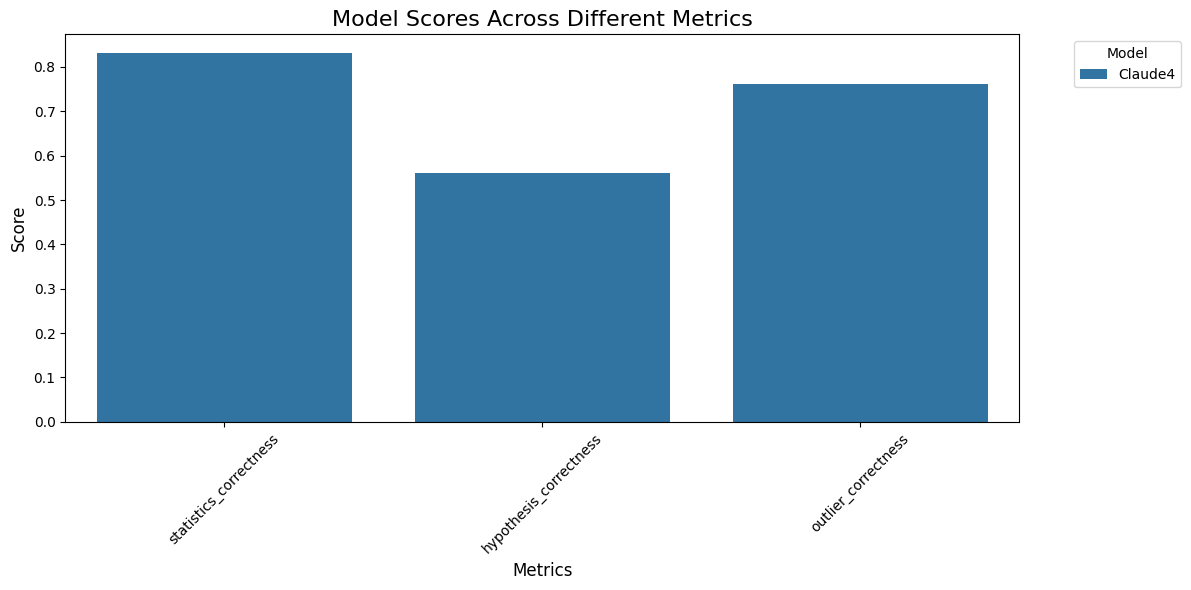

In [58]:
# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x="Metric", y="Score", hue="Model", data=all_scores_df_long)

# Customize the plot
plt.title("Model Scores Across Different Metrics", fontsize=16)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Show the plot
plt.show()